[housing.csv](https://https://www.kaggle.com/datasets/yasserh/housing-prices-dataset?resource=download

PART 1

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing (1).csv


In [ ]:
#Part 1: Data Cleaning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and display first 10 rows
df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
# 2. Shape, types, stats
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
# 3. Missing values
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
# 4. Duplicates
print(df.duplicated().sum())
df = df.drop_duplicates()

0


In [ ]:
# 5. Encode categorical columns
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [ ]:
# 6. Outlier removal - IQR
df_cleaned = df.copy()

for col in ['price', 'area']:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower) & (df_cleaned[col] <= upper)]

print(f"Rows before: {len(df)}, after removal: {len(df_cleaned)}")

Rows before: 545, after removal: 517


PART 2

In [ ]:
#Part 2: Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
# 1. Split
X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 2. Train
m = LinearRegression()
m.fit(X_tr, y_tr)

LinearRegression()

In [ ]:
# 3. Predict
preds = m.predict(X_te)

In [ ]:
# 4. Evaluate
MAE  = mean_absolute_error(y_te, preds)
MSE  = mean_squared_error(y_te, preds)
RMSE = np.sqrt(MSE)
R2   = r2_score(y_te, preds)

print("MAE :", MAE)
print("MSE :", MSE)
print("RMSE:", RMSE)
print("R2  :", R2)

MAE : 734127.1131194812
MSE : 954173744480.8966
RMSE: 976818.1737052688
R2  : 0.6747673447811053


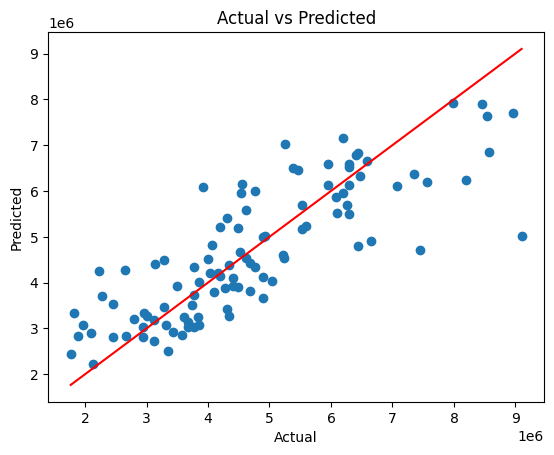

In [ ]:
# 5a. Actual vs Predicted
plt.scatter(y_te, preds)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r-')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

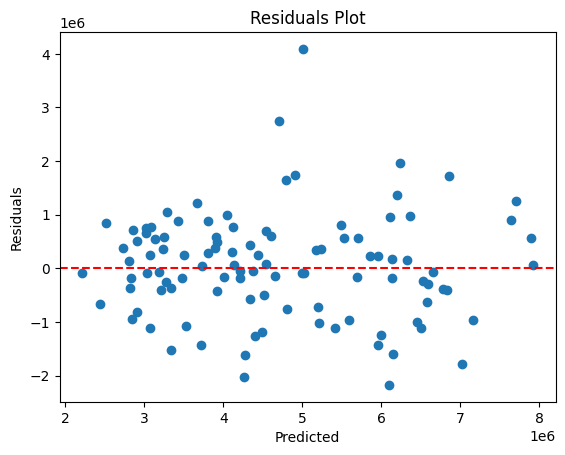

In [ ]:
# 5b. Residuals
plt.scatter(preds, y_te - preds)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.show()

In [ ]:
# 6. Coefficients table
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': m.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))

                        Feature    Coefficient
                airconditioning  867780.084698
                      bathrooms  700075.712694
                hotwaterheating  694272.523803
                       prefarea  513811.014778
                        stories  459516.904052
                      guestroom  417119.933267
                       mainroad  389351.463480
                       basement  309972.449583
                        parking  214359.721753
                       bedrooms   99674.796239
                           area     246.272416
furnishingstatus_semi-furnished   -2498.335812
   furnishingstatus_unfurnished -271269.983843


## Coefficient Analysis

so the biggest thing affecting price is airconditioning (867,780) which
honestly makes sense, especially in hot places - people really want AC
and will pay a lot more for it.

also noticed that unfurnished houses bring the price down the most which
also makes sense since furnished homes are move-in ready so buyers pay more.

kind of surprising that area has such a small coefficient (246) meaning
the size of the house matters less than features like AC and bathrooms.